<a href="https://colab.research.google.com/github/GUEST72/CSC311-Machine-Learning-projects/blob/main/assignment_2/Softmax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data handling & preprocessing
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix


# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# ----- Data -----
transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split train into train+val
train_size = int(0.8 * len(mnist_train))
val_size   = len(mnist_train) - train_size
train_ds, val_ds = random_split(mnist_train, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(mnist_test, batch_size=64, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 54.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.52MB/s]


In [ ]:
# ----- Model -----
class SoftmaxRegressionScratch(nn.Module):
    def __init__(self, num_features=28*28, num_classes=10):
        super().__init__()
        self.W = nn.Parameter(torch.randn(num_features, num_classes) * 0.01)
        self.b = nn.Parameter(torch.zeros(num_classes))

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return x @ self.W + self.b  # raw logits


# ----- Accuracy -----
def accuracy_multiclass(logits, y_true):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean()


In [ ]:


# ----- Training with Early Stopping -----
def train_softmax(model, train_loader, val_loader, epochs=10, learning_rate=0.1, patience=3):
    opt = torch.optim.SGD(model.parameters(), lr=learning_rate)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        total_loss, total_acc, total_samples = 0, 0, 0
        for xb, yb in train_loader:
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)  # expects raw logits & int64 targets

            opt.zero_grad()
            loss.backward()
            opt.step()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_acc  += accuracy_multiclass(logits, yb).item() * bs
            total_samples += bs

        train_losses.append(total_loss / total_samples)
        train_accs.append(total_acc / total_samples)

        # --- Validation ---
        model.eval()
        val_loss, val_acc, val_samples = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)
                bs = xb.size(0)
                val_loss += loss.item() * bs
                val_acc  += accuracy_multiclass(logits, yb).item() * bs
                val_samples += bs

        val_losses.append(val_loss / val_samples)
        val_accs.append(val_acc / val_samples)

        print(f"Epoch {epoch+1:02d}: "
              f"Train Loss={train_losses[-1]:.4f}, Train Acc={train_accs[-1]:.4f}, "
              f"Val Loss={val_losses[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")

        # --- Early Stopping Check ---
        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            patience_counter = 0
            best_model_state = model.state_dict()  # save best model
        else:
            patience_counter += 1
            print(f"  Patience counter {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("⏹ Early stopping triggered! Restoring best model weights...")
                model.load_state_dict(best_model_state)
                break

    return train_losses, val_losses, train_accs, val_accs


In [ ]:

# ----- Run -----
model = SoftmaxRegressionScratch()
train_losses,val_losses,train_accs,val_accs=train_softmax(model, train_loader, val_loader, epochs=10, learning_rate=0.1)

# Test accuracy
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        preds = torch.argmax(model(xb), dim=1)
        test_correct += (preds == yb).sum().item()
        test_total += yb.size(0)

print(f"Final Test Accuracy: {test_correct / test_total:.4f}")


Epoch 01: Train Loss=0.5033, Train Acc=0.8724, Val Loss=0.3777, Val Acc=0.8942
Epoch 02: Train Loss=0.3455, Train Acc=0.9035, Val Loss=0.3440, Val Acc=0.9012
Epoch 03: Train Loss=0.3198, Train Acc=0.9113, Val Loss=0.3294, Val Acc=0.9065
Epoch 04: Train Loss=0.3067, Train Acc=0.9145, Val Loss=0.3196, Val Acc=0.9082
Epoch 05: Train Loss=0.2978, Train Acc=0.9177, Val Loss=0.3141, Val Acc=0.9105
Epoch 06: Train Loss=0.2916, Train Acc=0.9190, Val Loss=0.3150, Val Acc=0.9081
  Patience counter 1/3
Epoch 07: Train Loss=0.2869, Train Acc=0.9201, Val Loss=0.3065, Val Acc=0.9127
Epoch 08: Train Loss=0.2828, Train Acc=0.9215, Val Loss=0.3050, Val Acc=0.9133
Epoch 09: Train Loss=0.2796, Train Acc=0.9229, Val Loss=0.3006, Val Acc=0.9133
Epoch 10: Train Loss=0.2770, Train Acc=0.9228, Val Loss=0.3024, Val Acc=0.9157
  Patience counter 1/3
Final Test Accuracy: 0.9221


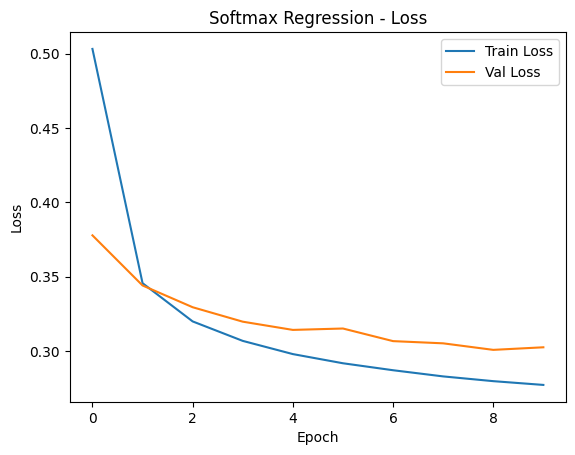

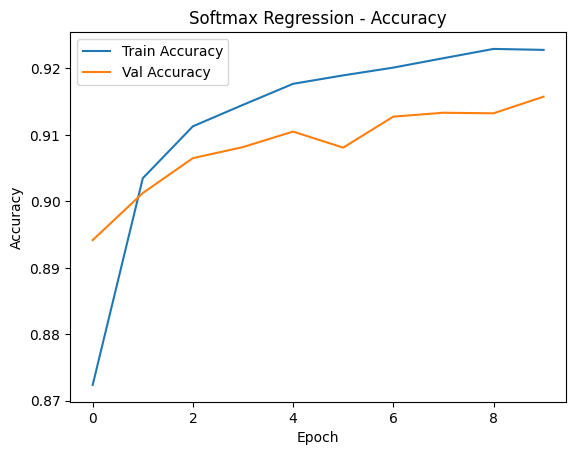

Final Test Accuracy: 0.9221


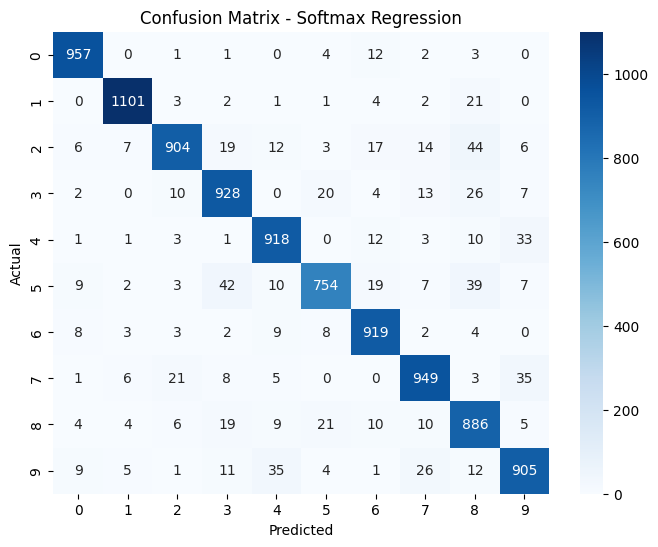

In [ ]:
# 6️⃣ Plot loss curves
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Softmax Regression - Loss")
plt.show()

# 7️⃣ Plot accuracy curves
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Softmax Regression - Accuracy")
plt.show()

# 8️⃣ Test evaluation & confusion matrix
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Final Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Softmax Regression")
plt.show()

In [ ]:
lr_results=[]
learning_rates=[0.001 ,0.01 , 0.1 , 1]
for lr in learning_rates:
    train_loader=DataLoader(train_ds,batch_size=64,shuffle=True)
    val_loader=DataLoader(val_ds,batch_size=64,shuffle=False)
    model=SoftmaxRegressionScratch()
    train_losses, val_losses, train_accs, val_accs=train_softmax(model,train_loader,val_loader,epochs=10,learning_rate=lr)
    lr_results.append(val_accs[-1])
bs_results=[]
batch_sizes=[16,32,64,128]
for bs in batch_sizes:
    train_loader=DataLoader(train_ds,batch_size=bs,shuffle=True)
    val_loader=DataLoader(val_ds,batch_size=bs,shuffle=False)
    model=SoftmaxRegressionScratch()
    train_losses, val_losses, train_accs, val_accs=train_softmax(model,train_loader,val_loader,epochs=10,learning_rate=0.1)
    bs_results.append(val_accs[-1])




Epoch 01: Train Loss=1.9670, Train Acc=0.6299, Val Loss=1.6916, Val Acc=0.7628
Epoch 02: Train Loss=1.5017, Train Acc=0.7837, Val Loss=1.3442, Val Acc=0.7995
Epoch 03: Train Loss=1.2305, Train Acc=0.8080, Val Loss=1.1358, Val Acc=0.8155
Epoch 04: Train Loss=1.0618, Train Acc=0.8205, Val Loss=1.0008, Val Acc=0.8258
Epoch 05: Train Loss=0.9488, Train Acc=0.8299, Val Loss=0.9071, Val Acc=0.8335
Epoch 06: Train Loss=0.8681, Train Acc=0.8365, Val Loss=0.8384, Val Acc=0.8388
Epoch 07: Train Loss=0.8075, Train Acc=0.8415, Val Loss=0.7857, Val Acc=0.8440
Epoch 08: Train Loss=0.7603, Train Acc=0.8464, Val Loss=0.7441, Val Acc=0.8473
Epoch 09: Train Loss=0.7223, Train Acc=0.8499, Val Loss=0.7103, Val Acc=0.8503
Epoch 10: Train Loss=0.6910, Train Acc=0.8533, Val Loss=0.6822, Val Acc=0.8530
Epoch 01: Train Loss=1.0554, Train Acc=0.8054, Val Loss=0.6808, Val Acc=0.8533
Epoch 02: Train Loss=0.5907, Train Acc=0.8635, Val Loss=0.5391, Val Acc=0.8671
Epoch 03: Train Loss=0.4991, Train Acc=0.8759, Val L

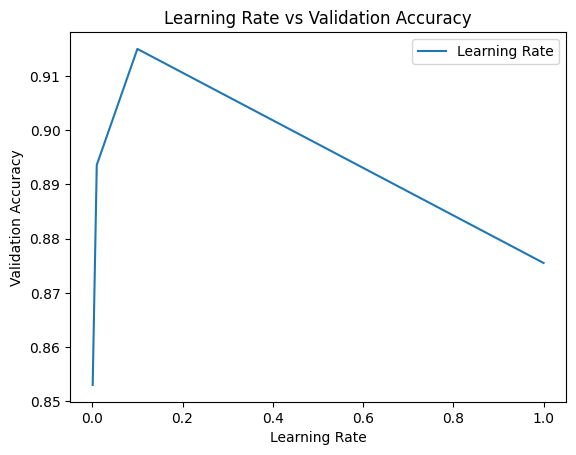

In [ ]:
plt.plot(learning_rates,lr_results,label='Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.title('Learning Rate vs Validation Accuracy')
plt.legend()
plt.show()

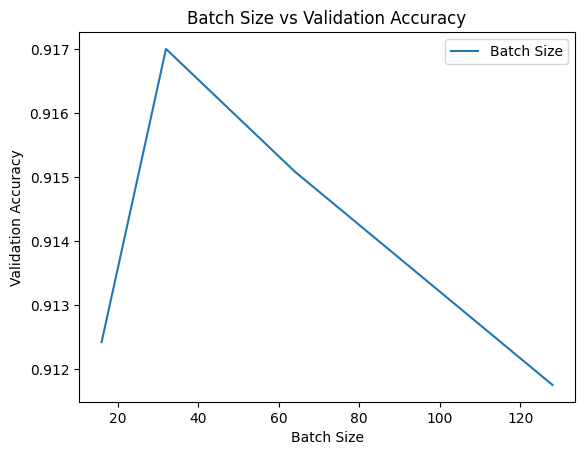

In [ ]:
plt.plot(batch_sizes,bs_results,label='Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy')
plt.title('Batch Size vs Validation Accuracy')
plt.legend()
plt.show()